# ESK Activity Visualization (HumEnv render)

This notebook loads an ESK SMPL pose file together with its **activity labels**, selects a specific activity segment (e.g. *Cut*), and renders a sequence of HumEnv skeletons across the segment into a static image.

Update the parameters in the next cell, then run the cells top to bottom.

/home/rimvydas/exact/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Available activities (29):
  Add: 34 segments
  Carry: 250 segments
  Clean: 31 segments
  Close: 42 segments
  Cut: 20 segments
  Dry: 9 segments
  Grab: 309 segments
  Hold: 58 segments
  Move: 85 segments
  Open: 47 segments
  Peel: 2 segments
  Pour: 11 segments
  Press: 10 segments
  Put: 225 segments
  Read: 22 segments
  Shake: 10 segments
  Stir: 30 segments
  Switch: 60 segments
  Tap: 1 segments
  Taste: 2 segments
  Touch: 12 segments
  Wash: 36 segments

Selected 'Stir' segment #0: frames 26293–27854 (1561 frames, 104.1s)
Sampling 4 frames every 2.0s (every 30 frames, covers 6.0s of 104.1s)


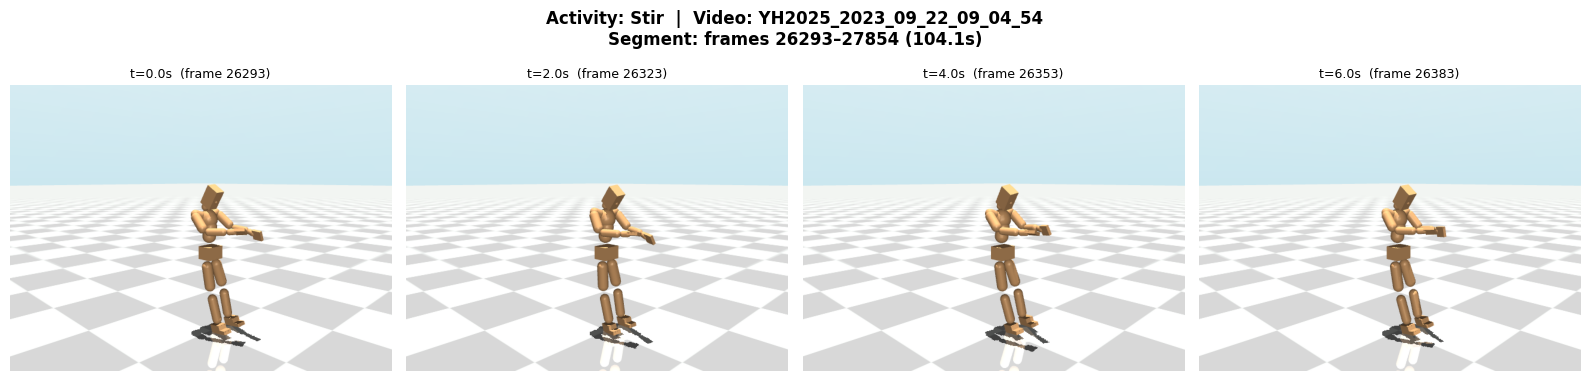

Saved to: outputs/activity_visualization.png


In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# Ensure MuJoCo rendering backend is set before importing humenv
os.environ["MUJOCO_GL"] = os.environ.get("MUJOCO_GL", "egl")
os.environ["PYOPENGL_PLATFORM"] = os.environ["MUJOCO_GL"]

import mujoco
from humenv import make_humenv

from exact.data.esk import load_pose_file, load_esk_labels

# ===================== User parameters =====================
esk_dir = Path("../esk")
video_id = "YH2025_2023_09_22_09_04_54"
label_type = "verbs"                 # "verbs", "nouns", or "activity"

# Activity to visualize (set to None to list all available labels)
target_activity = "Stir"
segment_index = 0                    # which segment instance (0 = longest)
sort_by_duration = True              # pick longest segment first

fps = 15                             # recording frame rate
step_seconds = 2.0                   # sample one frame every N seconds
max_frames = 4                      # max skeletons in the grid
output_image_path = Path("action_viz.png")

# ===================== Resolve paths ========================
pose_h5_path = esk_dir / "D2A_converted_pose_smpl" / f"{video_id}_pose3d_smpl.h5"
label_path = esk_dir / f"D2A_converted_label_{label_type}" / f"{video_id}_labels.pickle"

for p in [pose_h5_path, label_path]:
    if not p.exists():
        raise FileNotFoundError(p)

# ===================== Load labels ==========================
label_names, individuals, annotations = load_esk_labels(label_path)
print(f"Available activities ({len(label_names)}):")
activity_segments = {}
for idx, name in enumerate(label_names):
    segs = annotations[0][idx]
    n = len(segs) if hasattr(segs, "__len__") else 0
    activity_segments[str(name)] = segs
    if n > 0:
        print(f"  {name}: {n} segments")

if target_activity is None:
    raise SystemExit("Set target_activity above and re-run.")

# ===================== Pick segment =========================
segs = activity_segments[target_activity]
seg_list = [(int(s[0]), int(s[1])) for s in segs if int(s[1]) > int(s[0])]
if sort_by_duration:
    seg_list.sort(key=lambda s: -(s[1] - s[0]))
start, end = seg_list[segment_index]
duration_s = (end - start) / fps
print(f"\nSelected '{target_activity}' segment #{segment_index}: "
      f"frames {start}–{end} ({end - start} frames, {duration_s:.1f}s)")

# ===================== Load poses ===========================
poses, individual_id = load_pose_file(pose_h5_path)
segment_poses = poses[start:end]  # (seg_len, 24, 3) axis-angle rotations

# Sample one frame every step_seconds (fixed interval, not interpolated)
step_frames = max(1, int(round(step_seconds * fps)))
sample_indices = np.arange(0, len(segment_poses), step_frames)[:max_frames]
selected = segment_poses[sample_indices]
abs_indices = start + sample_indices

print(f"Sampling {len(selected)} frames every {step_seconds}s "
      f"(every {step_frames} frames, covers {sample_indices[-1]/fps:.1f}s of {duration_s:.1f}s)")

# ===================== SMPL → HumEnv qpos ==================
BASE_QUAT = np.zeros(4)
mujoco.mju_euler2Quat(BASE_QUAT, np.array([90.0, 0.0, 0.0]) * np.pi / 180.0, "XYZ")
STANDING_HEIGHT = 0.94


def axisangle_to_euler_xyz(aa):
    return Rotation.from_rotvec(aa).as_euler("XYZ")


def smpl_to_qpos(smpl_frame):
    qpos = np.zeros(76)
    qpos[0:3] = [0.0, 0.0, STANDING_HEIGHT]

    smpl_global_aa = smpl_frame[0]
    if np.linalg.norm(smpl_global_aa) > 1e-6:
        smpl_quat = np.zeros(4)
        angle = np.linalg.norm(smpl_global_aa)
        axis = smpl_global_aa / angle
        smpl_quat[0] = np.cos(angle / 2)
        smpl_quat[1:] = axis * np.sin(angle / 2)
        combined = np.zeros(4)
        mujoco.mju_mulQuat(combined, BASE_QUAT, smpl_quat)
        qpos[3:7] = combined
    else:
        qpos[3:7] = BASE_QUAT

    for j in range(23):
        qpos[7 + j * 3 : 7 + (j + 1) * 3] = axisangle_to_euler_xyz(smpl_frame[j + 1])
    return qpos


# ===================== Render ===============================
env, mp_info = make_humenv()
env.reset()
model = env.unwrapped.model
data = env.unwrapped.data

frames = []
for i, smpl_frame in enumerate(selected):
    data.qpos[:] = smpl_to_qpos(smpl_frame)
    data.qvel[:] = 0.0
    mujoco.mj_forward(model, data)
    frames.append(env.render())

env.close()
if mp_info is not None:
    mp_info["manager"].shutdown()

# ===================== Plot grid ============================
n = len(frames)
cols = min(4, n)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i in range(rows * cols):
    ax = axes[i]
    ax.axis("off")
    if i < n:
        ax.imshow(frames[i])
        t_rel = sample_indices[i] / fps
        ax.set_title(f"t={t_rel:.1f}s  (frame {abs_indices[i]})", fontsize=9)

fig.suptitle(f"Activity: {target_activity}  |  Video: {video_id}\n"
             f"Segment: frames {start}–{end} ({duration_s:.1f}s)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
output_image_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_image_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved to: {output_image_path}")